In [53]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Set random seed for reproducibility
torch.manual_seed(42)
np.random.seed(42)

# Check if CUDA is available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
print(f"PyTorch version: {torch.__version__}")

Using device: cuda
PyTorch version: 2.8.0+cu126


In [54]:
# Load Financial Data
df = pd.read_csv("order_dataset/financial_regression.csv")

# 1. Define Features (X) and Target (Y)
features = [
    'sp500 close', 'nasdaq close', 'silver close', 'oil close', 
    'platinum close', 'palladium close', 'usd_chf', 'eur_usd'
]
target = 'gold close'
cols_to_use = [target] + features

df_reg = df[cols_to_use].copy()

In [55]:
# 2. Handle Missing Data (Drop rows with NaN, same as Linear Regression)
df_reg.dropna(inplace=True)

# Extract features and target
X = df_reg[features].values.astype(np.float32)
y = df_reg[target].values.astype(np.float32)

print("Dataset Information (Financial Data):")
print(f"Number of samples: {X.shape[0]}")
print(f"Number of features: {X.shape[1]}")
print(f"Feature names: {features}")
print(f"Target: Gold Close Price")

# Split data into train and test sets (80-20 split)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)
print(f"Training set size: {X_train.shape[0]} samples")
print(f"Test set size: {X_test.shape[0]} samples")

# Normalize features using StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print("\n✓ Data normalized (mean=0, std=1)")

Dataset Information (Financial Data):
Number of samples: 3677
Number of features: 8
Feature names: ['sp500 close', 'nasdaq close', 'silver close', 'oil close', 'platinum close', 'palladium close', 'usd_chf', 'eur_usd']
Target: Gold Close Price
Training set size: 2941 samples
Test set size: 736 samples

✓ Data normalized (mean=0, std=1)


In [56]:
# Convert to PyTorch tensors
X_train_tensor = torch.FloatTensor(X_train_scaled)
y_train_tensor = torch.FloatTensor(y_train).reshape(-1, 1)
X_test_tensor = torch.FloatTensor(X_test_scaled)
y_test_tensor = torch.FloatTensor(y_test).reshape(-1, 1)

# Create TensorDatasets
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

# Create DataLoaders for batch processing
batch_size = 64
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print(f"Batch size: {batch_size}")
print(f"Number of training batches: {len(train_loader)}")
print(f"Number of test batches: {len(test_loader)}")

Batch size: 64
Number of training batches: 46
Number of test batches: 12


In [57]:
class RegressionModel(nn.Module):
    def __init__(self, input_size, hidden_size1=64, hidden_size2=32):
        super(RegressionModel, self).__init__()
        
        # Define layers
        self.fc1 = nn.Linear(input_size, hidden_size1)
        self.relu1 = nn.ReLU()
        self.fc2 = nn.Linear(hidden_size1, hidden_size2)
        self.relu2 = nn.ReLU()
        self.fc3 = nn.Linear(hidden_size2, 1)  # Output layer
        
    def forward(self, x):
        # Forward pass through the network
        x = self.fc1(x)
        x = self.relu1(x)
        x = self.fc2(x)
        x = self.relu2(x)
        x = self.fc3(x)
        return x

# Initialize model
input_size = X_train_scaled.shape[1]  # Number of features (8)
model = RegressionModel(input_size).to(device)

print(model)
print(f"\nModel moved to: {device}")

RegressionModel(
  (fc1): Linear(in_features=8, out_features=64, bias=True)
  (relu1): ReLU()
  (fc2): Linear(in_features=64, out_features=32, bias=True)
  (relu2): ReLU()
  (fc3): Linear(in_features=32, out_features=1, bias=True)
)

Model moved to: cuda


In [58]:
# Loss function: Mean Squared Error
criterion = nn.MSELoss()

# Optimizer: Adam with learning rate 0.001
learning_rate = 0.001
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

print(f"Loss function: {criterion}")
print(f"Optimizer: Adam")
print(f"Learning rate: {learning_rate}")

Loss function: MSELoss()
Optimizer: Adam
Learning rate: 0.001


In [59]:
# Training parameters
num_epochs = 100

# Track losses for visualization
train_losses = []
test_losses = []

print("Starting training...")
print("-" * 60)

for epoch in range(num_epochs):
    # Training phase
    model.train()
    train_loss = 0.0
    
    for X_batch, y_batch in train_loader:
        # Move data to device (GPU if available)
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)
        
        # 1. Forward pass: compute predictions
        predictions = model(X_batch)
        
        # 2. Compute loss
        loss = criterion(predictions, y_batch)
        
        # 3. Backward pass: compute gradients
        optimizer.zero_grad()  # Clear previous gradients
        loss.backward()  # Compute new gradients
        
        # 4. Update weights
        optimizer.step()
        
        train_loss += loss.item()
    
    # Average training loss for this epoch
    avg_train_loss = train_loss / len(train_loader)
    train_losses.append(avg_train_loss)
    
    # Evaluation phase (no gradient computation needed)
    model.eval()
    test_loss = 0.0
    
    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)
            predictions = model(X_batch)
            loss = criterion(predictions, y_batch)
            test_loss += loss.item()
    
    avg_test_loss = test_loss / len(test_loader)
    test_losses.append(avg_test_loss)
    
    # Print progress every 10 epochs
    if (epoch + 1) % 10 == 0:
        print(f"Epoch [{epoch+1}/{num_epochs}] | "
              f"Train Loss: {avg_train_loss:.4f} | "
              f"Test Loss: {avg_test_loss:.4f}")

print("-" * 60)
print("Training complete!")

Starting training...
------------------------------------------------------------
Epoch [10/100] | Train Loss: 427.1642 | Test Loss: 421.6264
Epoch [20/100] | Train Loss: 228.1738 | Test Loss: 227.9991
Epoch [30/100] | Train Loss: 149.5603 | Test Loss: 157.7619
Epoch [40/100] | Train Loss: 107.6532 | Test Loss: 115.0885
Epoch [50/100] | Train Loss: 81.6883 | Test Loss: 87.4256
Epoch [60/100] | Train Loss: 61.1173 | Test Loss: 65.5153
Epoch [70/100] | Train Loss: 46.9241 | Test Loss: 49.1979
Epoch [80/100] | Train Loss: 38.0536 | Test Loss: 39.0981
Epoch [90/100] | Train Loss: 32.3407 | Test Loss: 32.8344
Epoch [100/100] | Train Loss: 28.4174 | Test Loss: 28.9777
------------------------------------------------------------
Training complete!


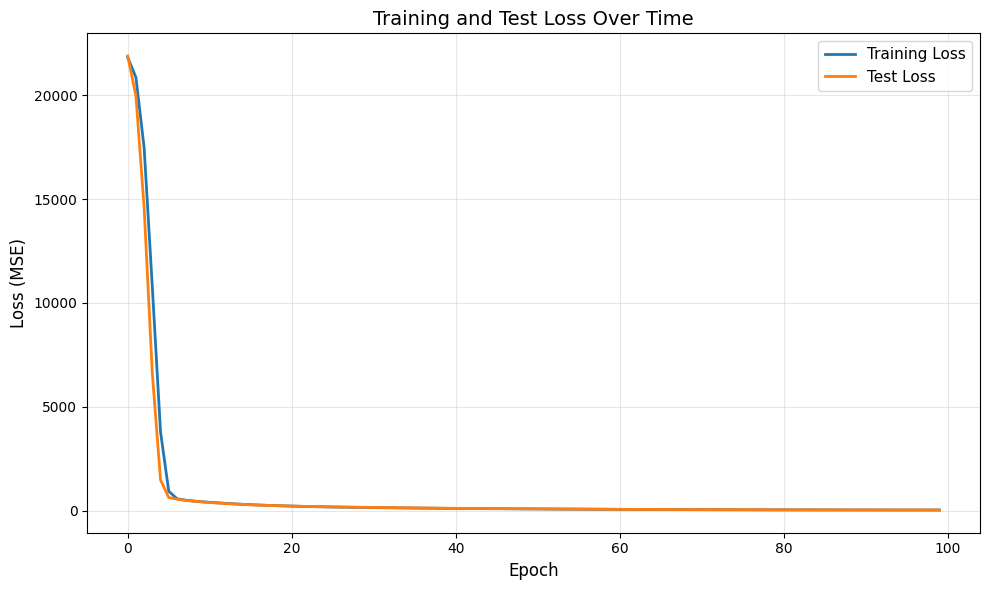

Final Training Loss: 28.4174
Final Test Loss: 28.9777


In [60]:
plt.figure(figsize=(10, 6))
plt.plot(train_losses, label='Training Loss', linewidth=2)
plt.plot(test_losses, label='Test Loss', linewidth=2)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss (MSE)', fontsize=12)
plt.title('Training and Test Loss Over Time', fontsize=14)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Final Training Loss: {train_losses[-1]:.4f}")
print(f"Final Test Loss: {test_losses[-1]:.4f}")

In [61]:
# Make predictions on test set
model.eval()
with torch.no_grad():
    X_test_device = X_test_tensor.to(device)
    y_pred = model(X_test_device).cpu().numpy()
    y_true = y_test_tensor.numpy()

# Calculate metrics
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

mse = mean_squared_error(y_true, y_pred)
mae = mean_absolute_error(y_true, y_pred)
r2 = r2_score(y_true, y_pred)
rmse = np.sqrt(mse)

print("Model Performance on Test Set:")
print("=" * 50)
print(f"Mean Squared Error (MSE):  {mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"R² Score: {r2:.4f}")
print("=" * 50)
print(f"\nInterpretation:")
print(f"On average, predictions are off by ${mae:.2f} USD")
print(f"Model explains {r2*100:.2f}% of the variance in gold prices")

Model Performance on Test Set:
Mean Squared Error (MSE):  29.4720
Root Mean Squared Error (RMSE): 5.4288
Mean Absolute Error (MAE): 3.8929
R² Score: 0.9695

Interpretation:
On average, predictions are off by $3.89 USD
Model explains 96.95% of the variance in gold prices


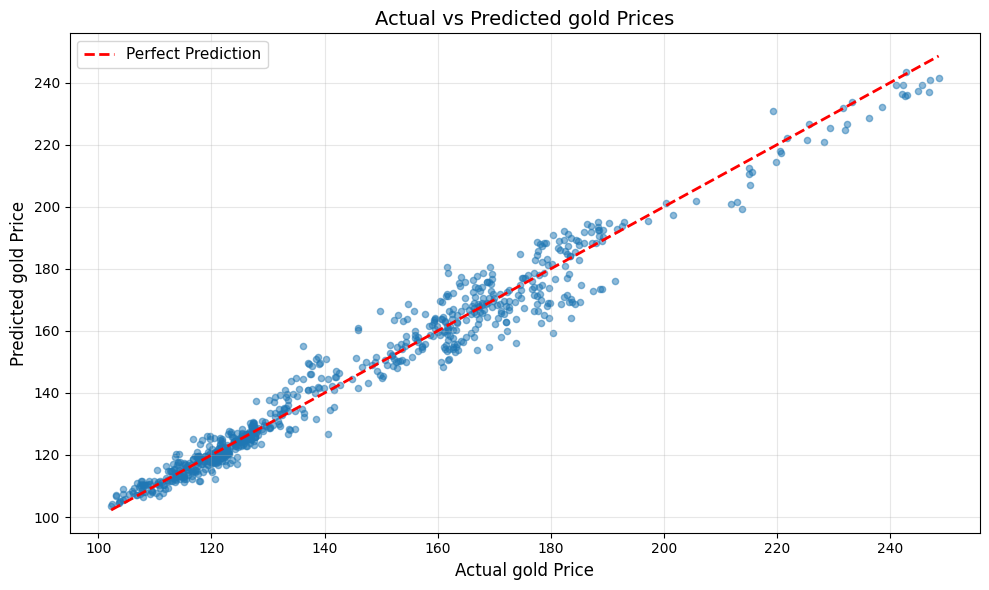


Sample Predictions (first 10 golds):
------------------------------------------------------------
      Actual |    Predicted |   Difference
------------------------------------------------------------
$       116 | $       117 | $        -1
$       114 | $       112 | $         1
$       247 | $       237 | $        10
$       165 | $       171 | $        -6
$       121 | $       119 | $         1
$       170 | $       168 | $         2
$       120 | $       118 | $         3
$       182 | $       189 | $        -7
$       125 | $       128 | $        -3
$       136 | $       145 | $        -8


In [62]:
# Create scatter plot of predictions vs actual values
plt.figure(figsize=(10, 6))
plt.scatter(y_true, y_pred, alpha=0.5, s=20)
plt.plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()], 
         'r--', lw=2, label='Perfect Prediction')
plt.xlabel('Actual gold Price', fontsize=12)
plt.ylabel('Predicted gold Price', fontsize=12)
plt.title('Actual vs Predicted gold Prices', fontsize=14)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Show some sample predictions
print("\nSample Predictions (first 10 golds):")
print("-" * 60)
print(f"{'Actual':>12} | {'Predicted':>12} | {'Difference':>12}")
print("-" * 60)
for i in range(min(10, len(y_true))):
    actual = y_true[i][0] 
    predicted = y_pred[i][0] 
    diff = actual - predicted
    print(f"${actual:>10,.0f} | ${predicted:>10,.0f} | ${diff:>10,.0f}")